# Customer Churn Prediction

An End-to-End Machine Learning Project for Telecommunications Customer Churn Prediction

This project develops a machine learning pipeline to predict whether a telecommunications customer is likely to churn.

The workflow covers the complete machine learning lifecycle:

**Data → Data Quality → EDA → Preprocessing → Modeling → Evaluation → Interpretation → Model Persistence → Deployment**

The final trained pipeline is designed to be reused by the project's FastAPI prediction service.

## 1. Business Problem

Customer churn is an important business problem for telecommunications companies.

When customers leave a service provider, the company may lose recurring revenue and may need to spend additional resources acquiring new customers.

The objective of this project is to build a binary classification model that estimates the probability of customer churn using demographic, service, contract, and billing information.

The model can support customer-retention workflows by identifying customers who may have a higher probability of leaving.

> **Important:** This model is intended as a predictive decision-support system. Model predictions represent statistical associations in the available data and should not be interpreted as causal conclusions.

## 2. Dataset Overview

This project uses the IBM Telco Customer Churn dataset.

Each observation represents a telecommunications customer and contains information about:

- Demographic characteristics
- Account information
- Subscribed services
- Contract type
- Payment method
- Customer tenure
- Monthly charges
- Total charges

The target variable is `Churn`.

| Value | Meaning |
|---|---|
| `Yes` | Customer churned |
| `No` | Customer did not churn |

The `customerID` column is treated as an identifier and is excluded from model training.

## 3. Imports and Configuration

The analysis uses pandas and NumPy for data manipulation, Matplotlib for visualization, and scikit-learn for preprocessing, model development, evaluation, and model persistence.

A fixed random seed is used where reproducibility is required.

In [1]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)

from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

DATA_PATH = "../data/Telco-Customer-Churn.csv"
MODEL_PATH = "../models/logistic_regression_pipeline.joblib"

## 4. Load the Dataset

The notebook is located inside the `notebooks/` directory.

Therefore, the dataset is loaded using a relative path that points to the project's `data/` directory.

In [2]:
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

display(df.head())

Dataset shape: 7,043 rows × 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 5. Initial Data Inspection

Before performing any preprocessing, we inspect the structure of the dataset.

This includes:

- Dataset dimensions
- Column names
- Data types
- Summary statistics
- Missing values
- Duplicate records

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
missing_summary = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .to_frame("Missing Values")
)

missing_summary["Missing Percentage"] = (
    missing_summary["Missing Values"] / len(df) * 100
)

display(
    missing_summary[
        missing_summary["Missing Values"] > 0
    ].round(2)
)

,Missing Values,Missing Percentage


In [6]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())

Duplicate rows: 0
Duplicate customer IDs: 0


## 6. Data Cleaning

The `TotalCharges` column contains blank values in the original dataset and is therefore initially interpreted as a string/object column.

We convert it to a numeric representation using `pd.to_numeric()`.

Invalid or blank values are converted to `NaN`, allowing them to be handled explicitly.

In [7]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("Missing TotalCharges:", df["TotalCharges"].isna().sum())

Missing TotalCharges: 11


In [8]:
display(
    df.loc[
        df["TotalCharges"].isna(),
        [
            "customerID",
            "tenure",
            "MonthlyCharges",
            "TotalCharges",
            "Churn"
        ]
    ]
)

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


### Handling Missing `TotalCharges`

The missing `TotalCharges` records correspond to customers with zero tenure.

There are only 11 such observations, representing approximately 0.16% of the original dataset.

Because these records do not provide enough information to reliably infer the customer's accumulated charges, they are removed rather than imputed using an unsupported assumption.

In [9]:
rows_before = len(df)

df = df.dropna(
    subset=["TotalCharges"]
).copy()

rows_after = len(df)

print("Rows before cleaning:", rows_before)
print("Rows after cleaning: ", rows_after)
print("Rows removed:        ", rows_before - rows_after)

Rows before cleaning: 7043
Rows after cleaning:  7032
Rows removed:         11


## 7. Target Distribution

Before developing a classifier, we examine the distribution of the target variable.

The dataset contains more customers who did not churn than customers who churned.

Because of this class imbalance, accuracy alone should not be used to evaluate model performance.

In [10]:
churn_distribution = pd.DataFrame({
    "Count": df["Churn"].value_counts(),
    "Percentage": (
        df["Churn"]
        .value_counts(normalize=True) * 100
    )
})

display(churn_distribution.round(2))

,Count,Percentage
Churn,,
No,5163,73.42
Yes,1869,26.58


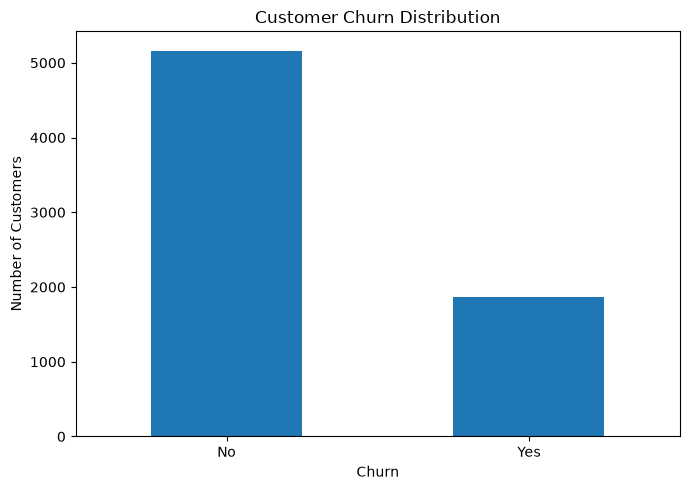

In [11]:
plt.figure(figsize=(7, 5))

df["Churn"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 8. Exploratory Data Analysis

Exploratory Data Analysis (EDA) helps us understand how customer characteristics are related to churn.

In this section, we investigate several important variables:

- Contract type
- Customer tenure
- Internet service
- Payment method
- Monthly charges

These relationships are descriptive and should not be interpreted as causal effects.

### 8.1 Contract Type and Churn

Contract type is an important customer-account characteristic.

We calculate the percentage of customers who churn within each contract category rather than comparing only raw customer counts.

This allows us to compare churn rates across groups with different numbers of customers.

In [12]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

display(contract_churn.round(2))

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.72,11.28
Two year,97.15,2.85


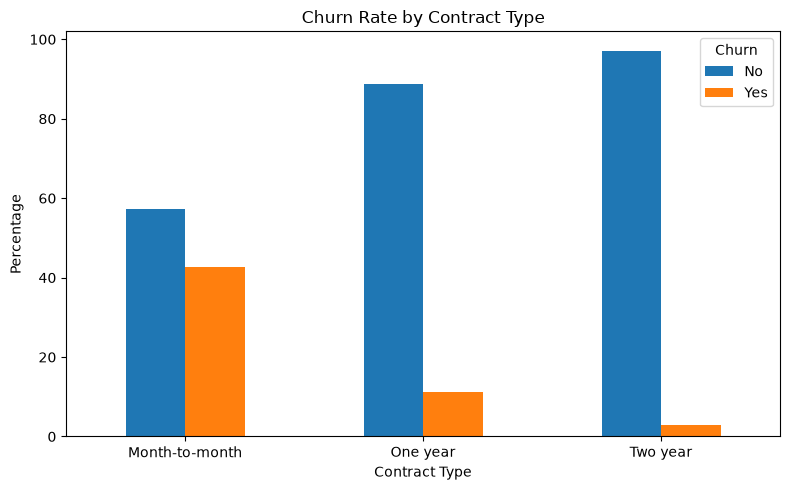

In [13]:
contract_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

### 8.2 Customer Tenure and Churn

Customer tenure represents the number of months a customer has been with the company.

To make the relationship easier to interpret, tenure is grouped into four ranges.

In [14]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=[
        "0-12 months",
        "13-24 months",
        "25-48 months",
        "49-72 months"
    ]
)

tenure_churn = pd.crosstab(
    df["tenure_group"],
    df["Churn"],
    normalize="index"
) * 100

display(tenure_churn.round(2))

Churn,No,Yes
tenure_group,,
0-12 months,52.32,47.68
13-24 months,71.29,28.71
25-48 months,79.61,20.39
49-72 months,90.49,9.51


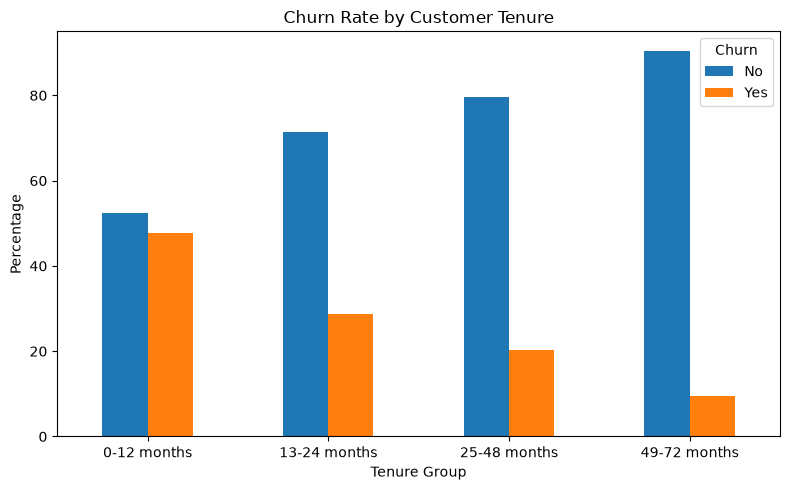

In [15]:
tenure_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

### 8.3 Internet Service and Churn

Internet service type may capture differences in customer products and service usage.

We compare churn rates across the available internet-service categories.

In [16]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

display(internet_churn.round(2))

Churn,No,Yes
InternetService,,
DSL,81.00,19.00
Fiber optic,58.11,41.89
No,92.57,7.43


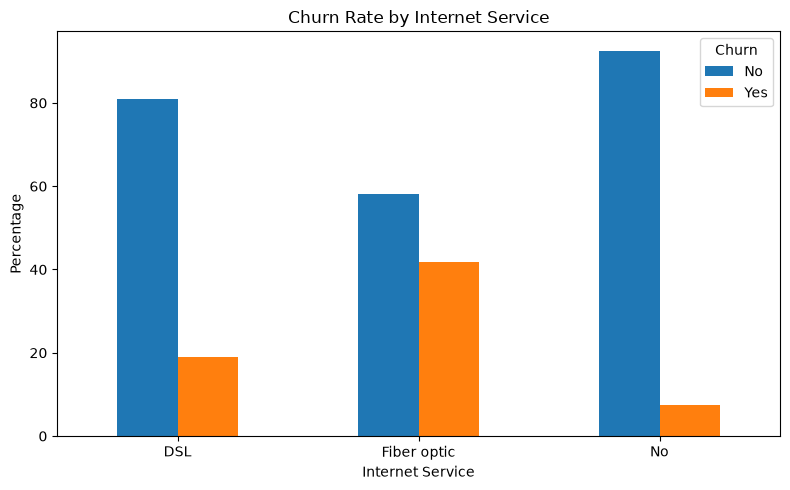

In [17]:
internet_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

### 8.4 Payment Method and Churn

Payment method may be associated with different customer behaviors and billing patterns.

We compare the churn rate for each payment method.

In [18]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

display(payment_churn.round(2))

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.27,16.73
Credit card (automatic),84.75,15.25
Electronic check,54.71,45.29
Mailed check,80.80,19.20


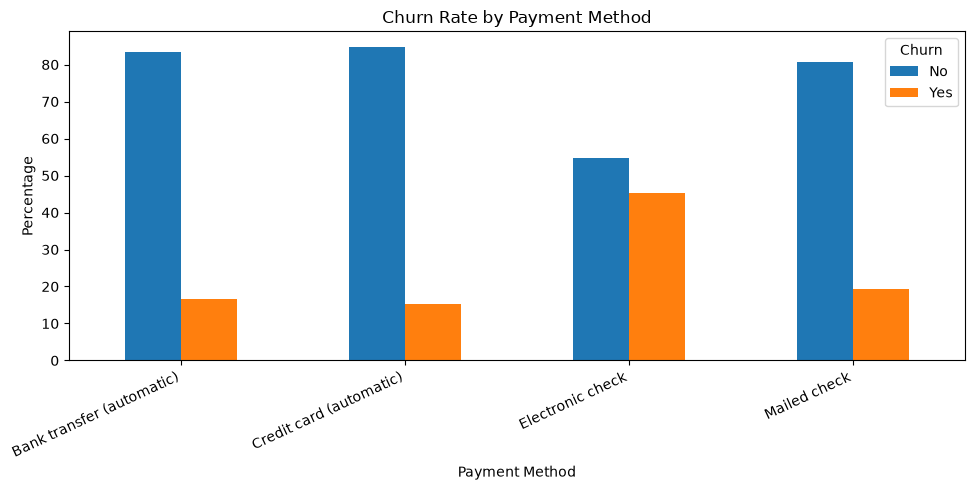

In [19]:
payment_churn.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Percentage")
plt.xticks(
    rotation=25,
    ha="right"
)
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

### 8.5 Monthly Charges and Churn

Monthly charges are a continuous numerical variable.

A boxplot allows us to compare the distribution of monthly charges between customers who churned and customers who remained.

<Figure size 800x500 with 0 Axes>

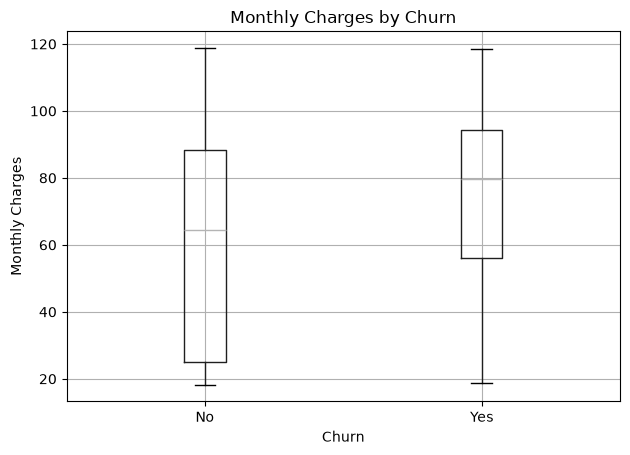

In [20]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="MonthlyCharges",
    by="Churn"
)

plt.suptitle("")
plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

### 8.6 Numerical Feature Summary

We also inspect the main numerical variables by churn status.

This provides a compact statistical summary before model development.

In [21]:
numerical_summary = (
    df.groupby("Churn")[
        [
            "tenure",
            "MonthlyCharges",
            "TotalCharges"
        ]
    ]
    .mean()
)

display(numerical_summary.round(2))

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.65,61.31,2555.34
Yes,17.98,74.44,1531.80


## 9. EDA Summary

The exploratory analysis highlights several differences between churned and retained customers.

The most visible patterns are associated with:

- contract type,
- customer tenure,
- internet service,
- payment method, and
- monthly charges.

These patterns motivate the use of both numerical and categorical features in the machine learning pipeline.

However, EDA alone cannot determine whether an individual variable will remain predictive after accounting for other variables. This is why we proceed with multivariate machine learning models.

## 10. Feature Preparation

The dataset contains an identifier, a target variable, and an EDA-only feature.

We remove:

- `customerID` — identifier, not a predictive feature
- `Churn` — target variable
- `tenure_group` — created only for exploratory analysis

All remaining variables are used as candidate predictors.

In [22]:
X = df.drop(
    columns=[
        "customerID",
        "Churn",
        "tenure_group"
    ]
)

y = df["Churn"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (7032, 19)
Target vector shape: (7032,)


### Feature Types

The preprocessing strategy depends on the type of each feature.

Numerical features will be standardized using `StandardScaler`.

Categorical features will be transformed using `OneHotEncoder`.

In [23]:
numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 4
Categorical features: 15


## 11. Train/Test Split

The dataset is divided into:

- **80% training data**
- **20% test data**

Stratification is used to preserve the class distribution of the target variable in both subsets.

The test set remains untouched during model development and is used only for final evaluation.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training features:", X_train.shape)
print("Test features:    ", X_test.shape)
print("Training target:  ", y_train.shape)
print("Test target:      ", y_test.shape)

Training features: (5625, 19)
Test features:     (1407, 19)
Training target:   (5625,)
Test target:       (1407,)


In [25]:
print("Training target distribution:")
display(
    (
        y_train
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .rename("Percentage")
    )
)

print("\nTest target distribution:")
display(
    (
        y_test
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .rename("Percentage")
    )
)

Training target distribution:


Churn
No     73.42
Yes    26.58
Name: Percentage, dtype: float64


Test target distribution:


Churn
No     73.42
Yes    26.58
Name: Percentage, dtype: float64

## 12. Preprocessing Pipeline

The dataset contains both numerical and categorical variables.

We use:

- `StandardScaler` for numerical features
- `OneHotEncoder` for categorical features

The transformations are combined using `ColumnTransformer`.

This preprocessing object will later be placed inside the machine learning pipeline.

Keeping preprocessing inside the pipeline is important because it prevents data leakage and guarantees that the same transformations are applied during training and inference.

In [26]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


## 13. Logistic Regression

Logistic Regression is used as the primary baseline model.

It is particularly useful for this project because:

- it is appropriate for binary classification,
- it produces probability estimates,
- it is relatively interpretable,
- it provides a strong baseline for tabular data, and
- its coefficients can be inspected after preprocessing.

The preprocessing and classifier are combined into a single pipeline.

In [27]:
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE
            )
        )
    ]
)

### Training the Logistic Regression Model

In [28]:
logistic_pipeline.fit(
    X_train,
    y_train
)

print("Logistic Regression training completed.")

Logistic Regression training completed.


## 14. Logistic Regression Evaluation

The model is evaluated using multiple metrics rather than accuracy alone.

The main metrics are:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Because churn is the positive class of interest, precision and recall are calculated specifically for `Yes`.

In [29]:
y_pred_logistic = logistic_pipeline.predict(X_test)

y_proba_logistic = (
    logistic_pipeline
    .predict_proba(X_test)[:, 1]
)

logistic_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(
        y_test,
        y_pred_logistic
    ),
    "Precision": precision_score(
        y_test,
        y_pred_logistic,
        pos_label="Yes"
    ),
    "Recall": recall_score(
        y_test,
        y_pred_logistic,
        pos_label="Yes"
    ),
    "F1": f1_score(
        y_test,
        y_pred_logistic,
        pos_label="Yes"
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        y_proba_logistic
    )
}

pd.DataFrame(
    [logistic_results]
).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.804,0.648,0.572,0.608,0.836


## 15. Decision Tree

A Decision Tree provides a non-linear alternative to Logistic Regression.

Unlike Logistic Regression, a tree can model non-linear decision boundaries and interactions between variables.

We first train an unconstrained Decision Tree to establish a baseline.

In [30]:
tree_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            DecisionTreeClassifier(
                random_state=RANDOM_STATE
            )
        )
    ]
)

tree_pipeline.fit(
    X_train,
    y_train
)

y_pred_tree = tree_pipeline.predict(
    X_test
)

y_proba_tree = (
    tree_pipeline
    .predict_proba(X_test)[:, 1]
)

In [31]:
tree_results = {
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(
        y_test,
        y_pred_tree
    ),
    "Precision": precision_score(
        y_test,
        y_pred_tree,
        pos_label="Yes",
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        y_pred_tree,
        pos_label="Yes",
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        y_pred_tree,
        pos_label="Yes",
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        y_proba_tree
    )
}

pd.DataFrame(
    [tree_results]
).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Decision Tree,0.731,0.493,0.497,0.495,0.656


## 16. Random Forest

Random Forest is an ensemble method that combines multiple decision trees.

It can capture more complex relationships than a single decision tree and generally provides more stable predictions.

A small grid search is used to select reasonable hyperparameters based on cross-validated ROC-AUC.

In [32]:
rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__min_samples_leaf": [1, 5, 10]
}

rf_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

rf_search.fit(
    X_train,
    y_train
)

best_rf = rf_search.best_estimator_

print("Best parameters:")
print(rf_search.best_params_)

print(
    f"\nBest cross-validation ROC-AUC: "
    f"{rf_search.best_score_:.3f}"
)

Best parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 10, 'model__n_estimators': 200}

Best cross-validation ROC-AUC: 0.848


In [33]:
y_pred_rf = best_rf.predict(
    X_test
)

y_proba_rf = (
    best_rf
    .predict_proba(X_test)[:, 1]
)

rf_results = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(
        y_test,
        y_pred_rf
    ),
    "Precision": precision_score(
        y_test,
        y_pred_rf,
        pos_label="Yes",
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        y_pred_rf,
        pos_label="Yes",
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        y_pred_rf,
        pos_label="Yes",
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        y_proba_rf
    )
}

pd.DataFrame(
    [rf_results]
).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.79,0.634,0.495,0.556,0.837


## 17. Model Comparison

We now compare the three candidate models using the same held-out test set.

The comparison includes multiple metrics because different metrics capture different aspects of classification performance.

In [34]:
model_comparison = pd.DataFrame([
    logistic_results,
    tree_results,
    rf_results
])

model_comparison = model_comparison.set_index(
    "Model"
)

display(
    model_comparison.round(3)
)

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.804,0.648,0.572,0.608,0.836
Decision Tree,0.731,0.493,0.497,0.495,0.656
Random Forest,0.790,0.634,0.495,0.556,0.837


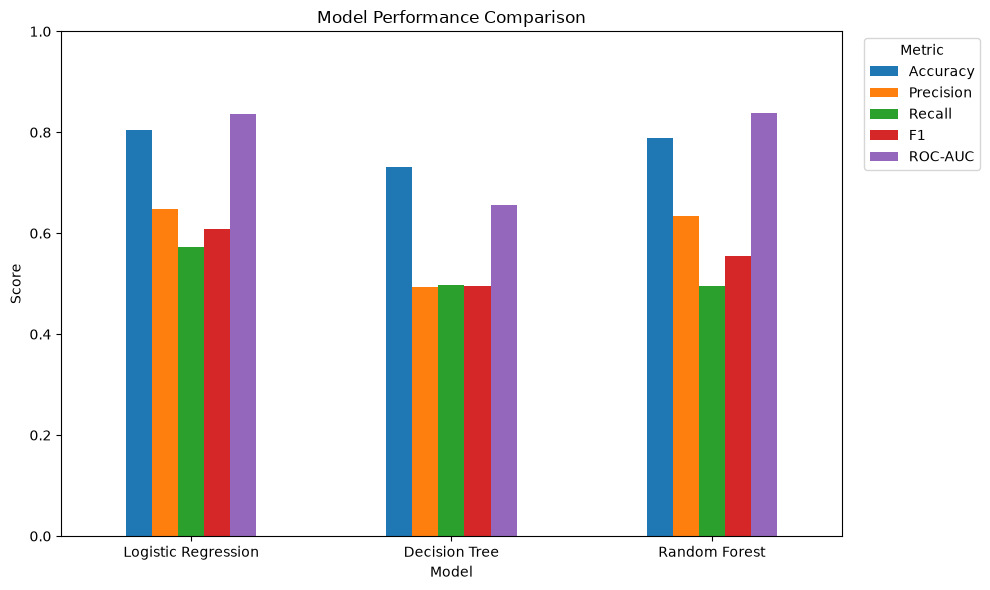

In [35]:
model_comparison.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## 18. Final Model Selection

For this project, the Logistic Regression pipeline is retained as the final production model.

The decision is based not only on predictive performance, but also on the project's production requirements:

- reproducible preprocessing,
- probability-based predictions,
- interpretability,
- simple deployment,
- and consistency with the model artifact consumed by the FastAPI service.

The final model is therefore the complete Logistic Regression pipeline containing both preprocessing and classification.

In [36]:
final_model = logistic_pipeline

y_pred = final_model.predict(
    X_test
)

y_proba = (
    final_model
    .predict_proba(X_test)[:, 1]
)

final_accuracy = accuracy_score(
    y_test,
    y_pred
)

final_precision = precision_score(
    y_test,
    y_pred,
    pos_label="Yes"
)

final_recall = recall_score(
    y_test,
    y_pred,
    pos_label="Yes"
)

final_f1 = f1_score(
    y_test,
    y_pred,
    pos_label="Yes"
)

final_auc = roc_auc_score(
    y_test,
    y_proba
)

final_metrics = pd.DataFrame([{
    "Accuracy": final_accuracy,
    "Precision": final_precision,
    "Recall": final_recall,
    "F1": final_f1,
    "ROC-AUC": final_auc
}])

display(
    final_metrics.round(3)
)

,Accuracy,Precision,Recall,F1,ROC-AUC
0,0.804,0.648,0.572,0.608,0.836


## 19. Detailed Classification Report

The classification report provides precision, recall, F1-score, and support for both classes.

For churn prediction, particular attention should be paid to the metrics for the `Yes` class.

In [37]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Churn",
            "Churn"
        ]
    )
)

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



## 20. Confusion Matrix

The confusion matrix provides a detailed view of the model's predictions.

It separates predictions into:

- True Negatives
- False Positives
- False Negatives
- True Positives

A false negative corresponds to a customer who actually churned but was predicted as non-churned.

In [38]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["No", "Yes"]
)

cm_df = pd.DataFrame(
    cm,
    index=[
        "Actual: No",
        "Actual: Yes"
    ],
    columns=[
        "Predicted: No",
        "Predicted: Yes"
    ]
)

display(cm_df)

,Predicted: No,Predicted: Yes
Actual: No,917,116
Actual: Yes,160,214


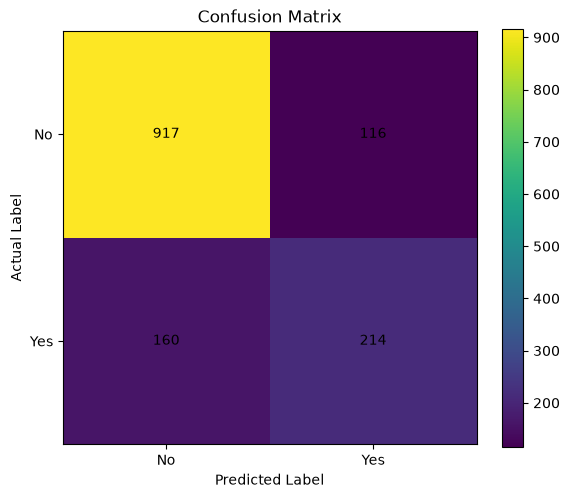

In [39]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    [0, 1],
    ["No", "Yes"]
)

plt.yticks(
    [0, 1],
    ["No", "Yes"]
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()
plt.show()

## 21. ROC Curve and ROC-AUC

ROC-AUC evaluates the model's ability to distinguish churned customers from non-churned customers across different classification thresholds.

An ROC-AUC of 0.5 corresponds to random ranking, while higher values indicate better discrimination.

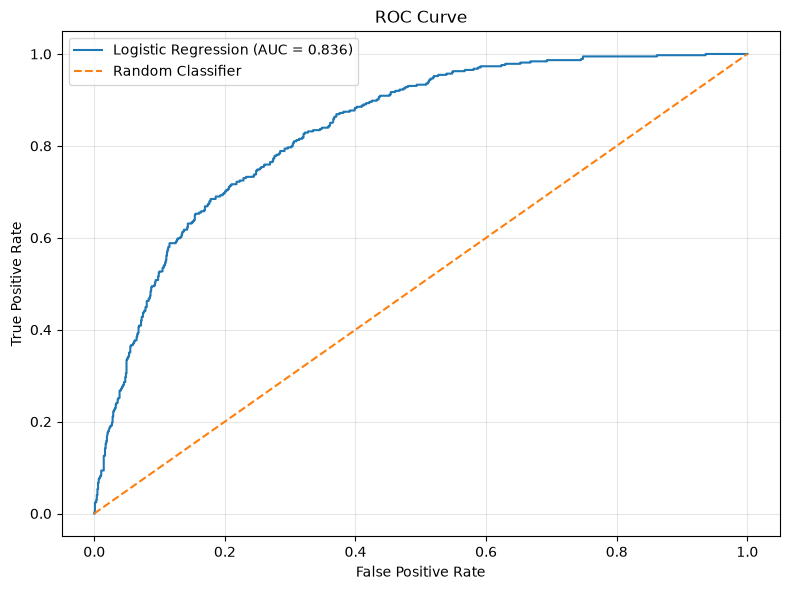

ROC-AUC: 0.836


In [40]:
fpr, tpr, _ = roc_curve(
    y_test,
    y_proba,
    pos_label="Yes"
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {final_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"ROC-AUC: {final_auc:.3f}")

## 22. Precision-Recall Curve

The Precision-Recall curve shows the trade-off between precision and recall across different classification thresholds.

This analysis is particularly useful when the positive class is important and the target distribution is not perfectly balanced.

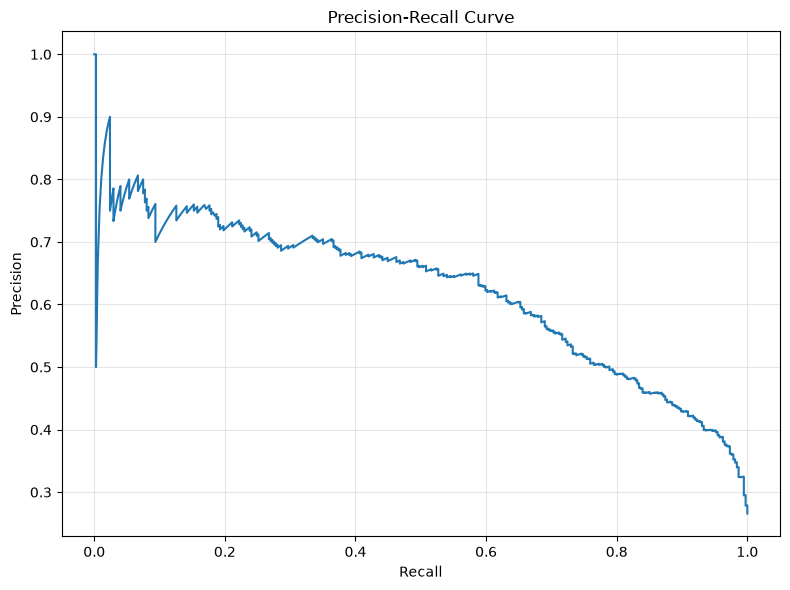

In [41]:
precision_values, recall_values, _ = precision_recall_curve(
    y_test,
    y_proba,
    pos_label="Yes"
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_values,
    precision_values
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 23. Classification Threshold Analysis

The default classification threshold is 0.5.

However, the optimal threshold depends on the business objective.

For example:

- A lower threshold may identify more potential churners but generate more false positives.
- A higher threshold may produce fewer false positives but miss more actual churners.

The following analysis evaluates several thresholds.

These results describe model behavior and should not be interpreted as a recommendation for a specific business threshold without an actual cost-benefit analysis.

In [42]:
thresholds = np.arange(
    0.1,
    1.0,
    0.1
)

threshold_results = []

for threshold in thresholds:

    threshold_prediction = np.where(
        y_proba >= threshold,
        "Yes",
        "No"
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            threshold_prediction,
            pos_label="Yes",
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            threshold_prediction,
            pos_label="Yes",
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            threshold_prediction,
            pos_label="Yes",
            zero_division=0
        ),
        "Accuracy": accuracy_score(
            y_test,
            threshold_prediction
        )
    })

threshold_results_df = pd.DataFrame(
    threshold_results
)

display(
    threshold_results_df.round(3)
)

,Threshold,Precision,Recall,F1,Accuracy
0,0.1,0.399,0.947,0.561,0.606
1,0.2,0.458,0.869,0.600,0.692
2,0.3,0.511,0.759,0.611,0.743
3,0.4,0.579,0.684,0.627,0.784
4,0.5,0.648,0.572,0.608,0.804
5,0.6,0.679,0.385,0.491,0.788
6,0.7,0.759,0.168,0.276,0.765
7,0.8,0.875,0.019,0.037,0.738
8,0.9,0.000,0.000,0.000,0.734


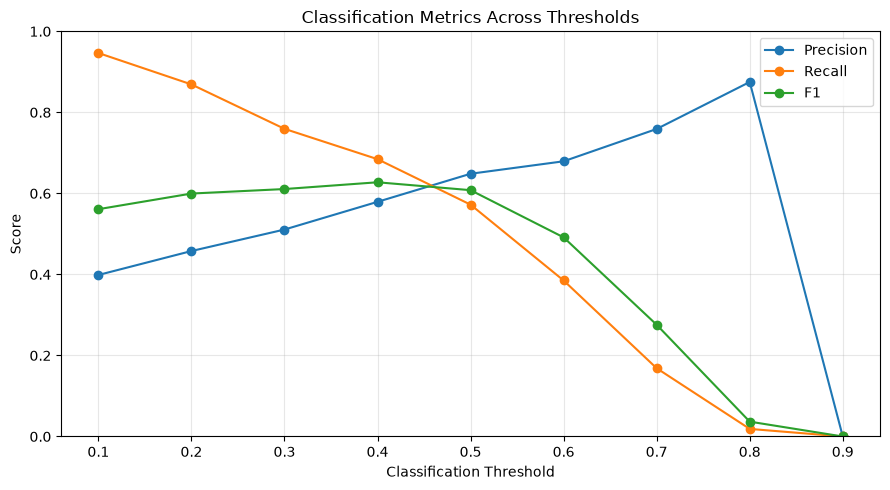

In [43]:
threshold_results_df.set_index(
    "Threshold"
)[
    [
        "Precision",
        "Recall",
        "F1"
    ]
].plot(
    figsize=(9, 5),
    marker="o"
)

plt.title(
    "Classification Metrics Across Thresholds"
)

plt.xlabel(
    "Classification Threshold"
)

plt.ylabel(
    "Score"
)

plt.ylim(0, 1)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 24. Model Interpretation

One advantage of Logistic Regression is that its coefficients can provide insight into how transformed features are associated with the predicted log-odds of churn.

Because the pipeline includes scaling and one-hot encoding, the coefficients must be interpreted in the context of those transformations.

These coefficients represent model associations and should not be interpreted as causal effects.

In [44]:
feature_names = (
    final_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    final_model
    .named_steps["model"]
    .coef_[0]
)

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_df["AbsoluteCoefficient"] = (
    coefficient_df["Coefficient"].abs()
)

coefficient_df = coefficient_df.sort_values(
    "AbsoluteCoefficient",
    ascending=False
)

display(
    coefficient_df.head(20).round(3)
)

,Feature,Coefficient,AbsoluteCoefficient
1,num__tenure,-1.352,1.352
38,cat__Contract_Two year,-0.779,0.779
3,num__TotalCharges,0.644,0.644
15,cat__InternetService_DSL,-0.616,0.616
36,cat__Contract_Month-to-month,0.614,0.614
16,cat__InternetService_Fiber optic,0.590,0.590
2,num__MonthlyCharges,-0.541,0.541
39,cat__PaperlessBilling_No,-0.300,0.300
12,cat__MultipleLines_No,-0.293,0.293
17,cat__InternetService_No,-0.284,0.284


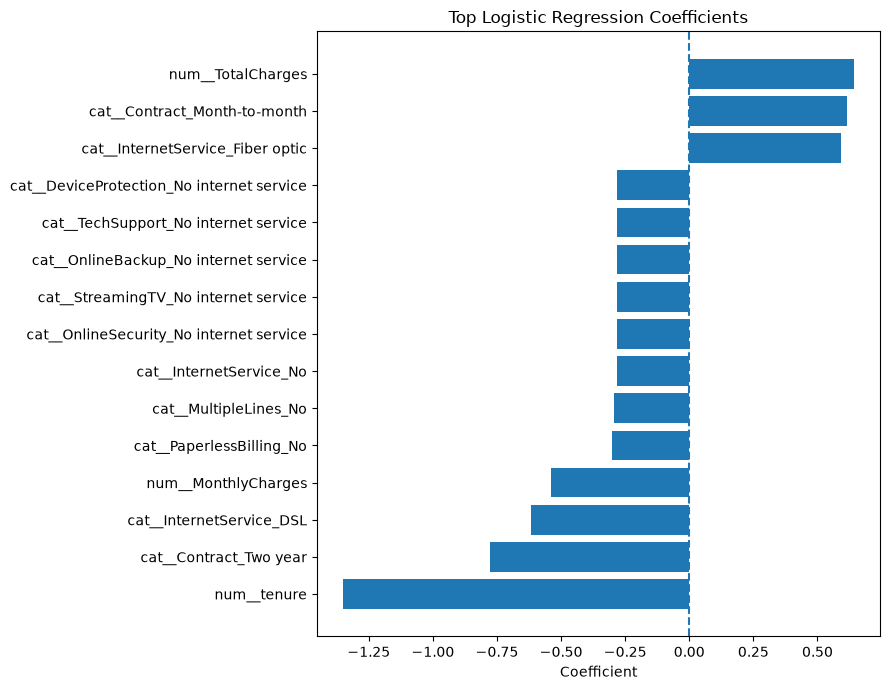

In [45]:
top_coefficients = (
    coefficient_df
    .head(15)
    .sort_values("Coefficient")
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_coefficients["Feature"],
    top_coefficients["Coefficient"]
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "Top Logistic Regression Coefficients"
)

plt.xlabel(
    "Coefficient"
)

plt.tight_layout()
plt.show()

## 25. Permutation Importance

Permutation importance measures how much model performance changes when the values of a feature are randomly shuffled.

This provides a complementary interpretation method based on predictive usefulness rather than model coefficients.

A higher permutation importance indicates that the model's performance depends more strongly on that feature under the chosen evaluation setup.

Permutation importance should be interpreted as predictive importance, not causality.

In [46]:
permutation = permutation_importance(
    final_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="accuracy"
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": permutation.importances_mean
}).sort_values(
    "Importance",
    ascending=False
)

display(
    importance_df.head(15).round(4)
)

,Feature,Importance
4,tenure,0.1122
7,InternetService,0.0515
17,MonthlyCharges,0.0321
18,TotalCharges,0.0316
14,Contract,0.0260
15,PaperlessBilling,0.0106
16,PaymentMethod,0.0072
11,TechSupport,0.0068
13,StreamingMovies,0.0067
6,MultipleLines,0.0065


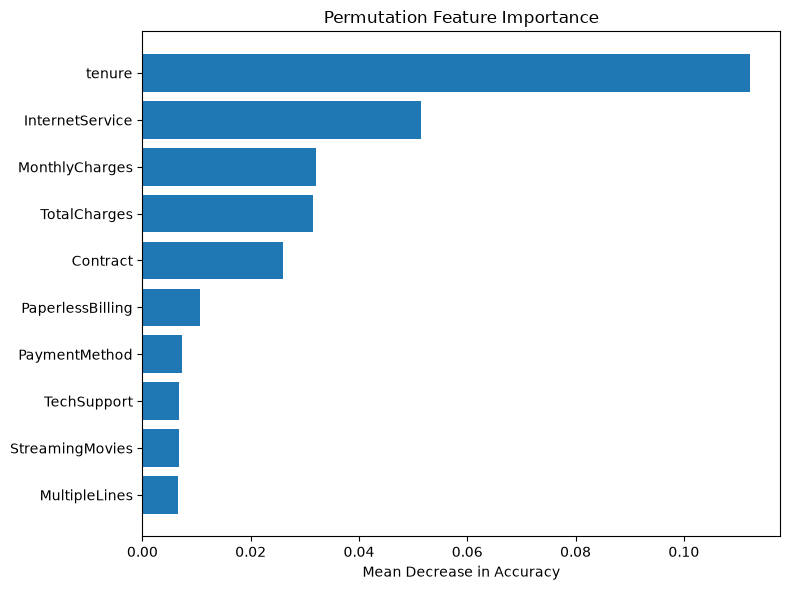

In [47]:
top_importance = (
    importance_df
    .head(10)
    .sort_values("Importance")
)

plt.figure(figsize=(8, 6))

plt.barh(
    top_importance["Feature"],
    top_importance["Importance"]
)

plt.title(
    "Permutation Feature Importance"
)

plt.xlabel(
    "Mean Decrease in Accuracy"
)

plt.tight_layout()
plt.show()

## 26. Model Persistence

The complete preprocessing and Logistic Regression model are saved as a single `joblib` artifact.

This is important for deployment because the production application should apply exactly the same preprocessing transformations used during training.

The saved artifact can therefore be loaded directly by the FastAPI service.

In [48]:
os.makedirs(
    os.path.dirname(MODEL_PATH),
    exist_ok=True
)

joblib.dump(
    final_model,
    MODEL_PATH
)

print(
    f"Model saved to: {MODEL_PATH}"
)

Model saved to: ../models/logistic_regression_pipeline.joblib


## 27. Model Reload Verification

After saving the model, we reload it from disk and verify that its predictions are identical to the predictions generated before serialization.

This provides a simple reproducibility check for the persisted model artifact.

In [49]:
loaded_model = joblib.load(
    MODEL_PATH
)

loaded_predictions = (
    loaded_model.predict(X_test)
)

print(
    "Predictions identical:",
    np.array_equal(
        loaded_predictions,
        y_pred
    )
)

Predictions identical: True


## 28. Example Customer Prediction

The saved pipeline can now be used to predict churn for a new customer.

The input contains the original raw feature representation.

No manual encoding or scaling is required because these transformations are already included inside the pipeline.

In [50]:
new_customer = pd.DataFrame({
    "gender": ["Female"],
    "SeniorCitizen": [0],
    "Partner": ["Yes"],
    "Dependents": ["No"],
    "tenure": [5],
    "PhoneService": ["Yes"],
    "MultipleLines": ["No"],
    "InternetService": ["Fiber optic"],
    "OnlineSecurity": ["No"],
    "OnlineBackup": ["No"],
    "DeviceProtection": ["No"],
    "TechSupport": ["No"],
    "StreamingTV": ["Yes"],
    "StreamingMovies": ["Yes"],
    "Contract": ["Month-to-month"],
    "PaperlessBilling": ["Yes"],
    "PaymentMethod": ["Electronic check"],
    "MonthlyCharges": [85.0],
    "TotalCharges": [425.0]
})

display(new_customer)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,5,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,85.0,425.0


In [51]:
prediction = loaded_model.predict(
    new_customer
)[0]

churn_probability = (
    loaded_model
    .predict_proba(new_customer)[0, 1]
)

print("Prediction:", prediction)
print(
    f"Churn probability: "
    f"{churn_probability:.3f}"
)

Prediction: Yes
Churn probability: 0.772


## 29. Conclusions

This notebook demonstrated an end-to-end machine learning workflow for customer churn prediction.

The workflow included:

1. Data loading and quality assessment
2. Data cleaning
3. Exploratory Data Analysis
4. Feature preparation
5. Stratified train/test splitting
6. Reproducible preprocessing
7. Logistic Regression
8. Decision Tree
9. Random Forest
10. Model comparison
11. Final model evaluation
12. Threshold analysis
13. Model interpretation
14. Model persistence
15. Example customer prediction

The final Logistic Regression pipeline achieved a ROC-AUC of approximately **0.836** on the held-out test set in the current project version.

The complete preprocessing and model pipeline was saved as a single artifact and can be consumed by the project's FastAPI application.

## 30. Key Takeaways

Several important patterns were identified during exploratory analysis.

Customer tenure and contract characteristics showed meaningful differences in churn rates across groups. Other service and billing variables also provided useful predictive information.

The modeling results demonstrate that a relatively simple and interpretable Logistic Regression pipeline can provide useful predictive performance on this tabular classification problem.

Importantly, the model is not used in isolation. The project extends beyond model training into:

- REST API deployment
- Docker containerization
- Docker Compose
- Prometheus monitoring
- Grafana dashboards
- Automated testing
- GitHub Actions CI/CD
- Container publishing through GHCR
- Automated deployment

This connects the notebook-based analysis to a broader production-oriented machine learning workflow.

## 31. Future Improvements

Potential improvements for future versions include:

- probability calibration,
- more extensive hyperparameter optimization,
- additional classification algorithms,
- systematic cross-validation,
- business-specific cost modeling,
- model explainability with SHAP,
- data-drift monitoring,
- automated model retraining,
- cloud deployment, and
- automated model performance monitoring.

These improvements would further extend the project toward a complete production machine learning lifecycle.

## Final Note

This notebook focuses on reproducibility, interpretability, and production readiness.

The final model artifact generated here is used by the project's FastAPI service, allowing the same preprocessing and prediction logic to be reused outside the notebook environment.

**Project repository:** `RasulAramian/ml-customer-churn`